In [ ]:
!pip install ultralytics
!pip install kaggle
!pip install tensorflow
!pip install opencv-python
!pip install albumentations
!pip install --upgrade ultralytics ray

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.5/983.5 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 43.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 90.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninsta

In [ ]:
import os
import random
import pandas as pd
import cv2
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, Video
from ultralytics import YOLO
from tqdm.notebook import tqdm
import seaborn as sns
sns.set(style='darkgrid')
import pathlib
import glob
import warnings
warnings.filterwarnings('ignore')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!mkdir ~/.kaggle
!cp /content/drive/MyDrive/ColabNotebooks/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d pkdarabi/cardetection

Dataset URL: https://www.kaggle.com/datasets/pkdarabi/cardetection
License(s): Attribution 4.0 International (CC BY 4.0)


In [ ]:
!unzip cardetection.zip

Streaming output truncated to the last 5000 lines.
  inflating: car/train/labels/00000_00003_00024_png.rf.08957035e670072dbb22d8f9905e9b84.txt  
  inflating: car/train/labels/00000_00003_00025_png.rf.11e558fae394d310693ee9223b8962ca.txt  
  inflating: car/train/labels/00000_00003_00026_png.rf.1f6b33373353f896f2c2025ffd264e51.txt  
  inflating: car/train/labels/00000_00003_00026_png.rf.a3b6c2dcd4ee9a8064667b7bb266590b.txt  
  inflating: car/train/labels/00000_00003_00027_png.rf.c1381ed46ee0d7e21877ea3d7ef86127.txt  
  inflating: car/train/labels/00000_00003_00029_png.rf.8e24d2606537779612888c6a06c7043d.txt  
  inflating: car/train/labels/00000_00004_00000_png.rf.45dccdbf08ed12f25d7742d8bf88c102.txt  
  inflating: car/train/labels/00000_00004_00001_png.rf.557d3494b3e633e29069a6f42918334e.txt  
  inflating: car/train/labels/00000_00004_00002_png.rf.3e3e95e1ba16cac885d3de7864a40fb4.txt  
  inflating: car/train/labels/00000_00004_00003_png.rf.9c6ba4d0186eec82a26bddc9a1204efb.txt  
  inflati

In [ ]:
# Step 4: Data Augmentation Setup (Using YOLOv8 Built-in Augmentations)
hyp_yaml = """
flipud: 0.0       # Vertical flip probability
fliplr: 0.5       # Horizontal flip probability
hsv_h: 0.015      # Hue shift
hsv_s: 0.7        # Saturation shift
hsv_v: 0.4        # Brightness shift
mosaic: 1.0       # Mosaic augmentation
rotate: 40        # Rotation degrees
scale: 0.5        # Scaling factor
translate: 0.1    # Translation factor
shear: 0.0        # Shearing factor
perspective: 0.0  # Perspective distortion
blur: 0.1         # Motion blur
"""

# Save the hyp.yaml for YOLOv8
with open("/content/hyp.yaml", "w") as f:
    f.write(hyp_yaml)


In [ ]:
# List all images in each directory
dataset_path = '/content/car'
train_images = glob.glob(os.path.join(dataset_path, 'train/images/*.jpg'))
val_images = glob.glob(os.path.join(dataset_path, 'valid/images/*.jpg'))
test_images = glob.glob(os.path.join(dataset_path, 'test/images/*.jpg'))

# Print the count of images in each directory

print("Training Images:", len(train_images))
print("Validation Images:", len(val_images))
print("Test Images:", len(test_images))

Training Images: 3530
Validation Images: 801
Test Images: 638


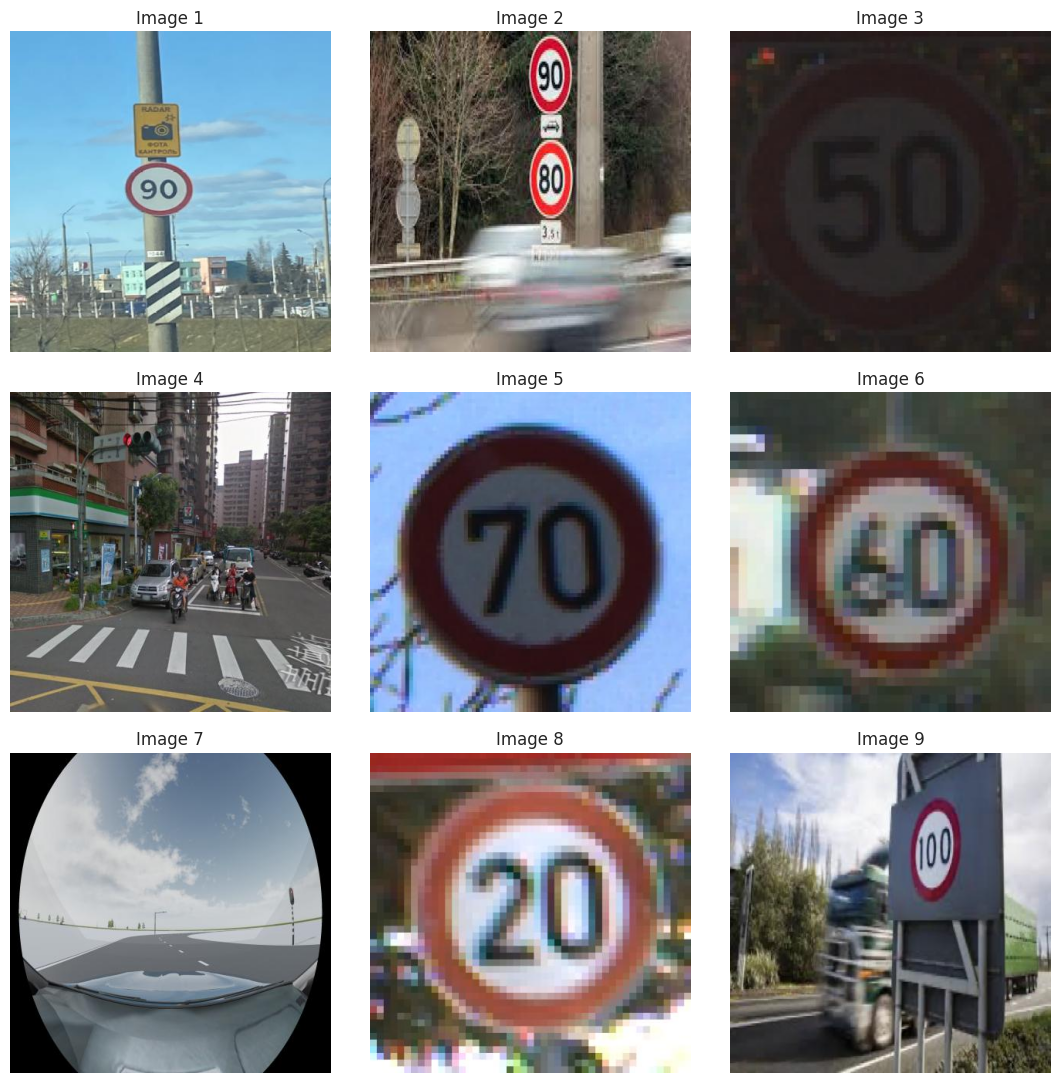

In [ ]:
Image_dir = '/content/car/train/images'

num_samples = 9
image_files = os.listdir(Image_dir)

# Randomly select num_samples images
rand_images = random.sample(image_files, num_samples)

fig, axes = plt.subplots(3, 3, figsize=(11, 11))

for i in range(num_samples):
    image = rand_images[i]
    ax = axes[i // 3, i % 3]
    ax.imshow(plt.imread(os.path.join(Image_dir, image)))
    ax.set_title(f'Image {i+1}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Get the size of the image
image = cv2.imread("/content/car/train/images/00000_00000_00012_png.rf.23f94508dba03ef2f8bd187da2ec9c26.jpg")
h, w, c = image.shape
print(f"The image has dimensions {w}x{h} and {c} channels.")

The image has dimensions 416x416 and 3 channels.


100%|██████████| 49.7M/49.7M [00:03<00:00, 14.8MB/s]



image 1/1 /content/car/train/images/000074_jpg.rf.e6d7b4e5c92cced6e6589083482fca75.jpg: 640x640 1 stop sign, 10.2ms
Speed: 16.6ms preprocess, 10.2ms inference, 359.7ms postprocess per image at shape (1, 3, 640, 640)


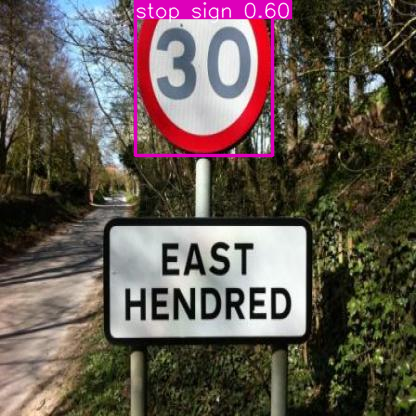

In [ ]:
# Use a pretrained YOLOv8m model
model = YOLO("yolov8m.pt")

# Use the model to detect object
image = "/content/car/train/images/000074_jpg.rf.e6d7b4e5c92cced6e6589083482fca75.jpg"
result_predict = model.predict(source = image, imgsz=(640))

# show results
plot = result_predict[0].plot()
plot = cv2.cvtColor(plot, cv2.COLOR_BGR2RGB)
display(Image.fromarray(plot))

In [ ]:
# NMS threshold adjustment
nms_thresholds = [0.6]
for nms in nms_thresholds:
    results = model.predict(source="/content/car/test/images", conf=0.5, iou=nms, save=True)
    print(f"Results with NMS Threshold {nms}: {results}")

Streaming output truncated to the last 5000 lines.
       [[ 56,  44,  26],
        [ 57,  45,  27],
        [ 58,  46,  28],
        ...,
        [ 65,  54,  32],
        [ 61,  50,  28],
        [ 58,  47,  25]],

       [[ 70,  58,  40],
        [ 72,  60,  42],
        [ 71,  59,  41],
        ...,
        [ 62,  51,  29],
        [ 61,  50,  28],
        [ 57,  46,  24]]], dtype=uint8)
orig_shape: (416, 416)
path: '/content/car/test/images/road400_png.rf.03186a0125d7e8f9ccbad9322201c91a.jpg'
probs: None
save_dir: 'runs/detect/predict'
speed: {'preprocess': 2.6605969999877743, 'inference': 9.283673000027193, 'postprocess': 0.6960839999692325}, ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'benc

In [ ]:
# Step 8: Define Helper Functions for Data Augmentation and Preprocessing
def augment_image(image):
    # Define augmentation pipeline using Albumentations
    image = image.astype(np.float32) / 255.0
    augmentations = A.Compose([
        A.RandomBrightnessContrast(p=0.6),  # brightness changes
        A.Rotate(limit=40, p=0.5),  # Random Rotation
        A.HorizontalFlip(p=0.5),  # Horizontal Flipping
        A.MotionBlur(p=0.1),  # Motion Blur
        ToTensorV2()  # Convert to Tensor for YOLOv8
    ])
    augmented_image = augmentations(image=image)
    return augmented_image['image']

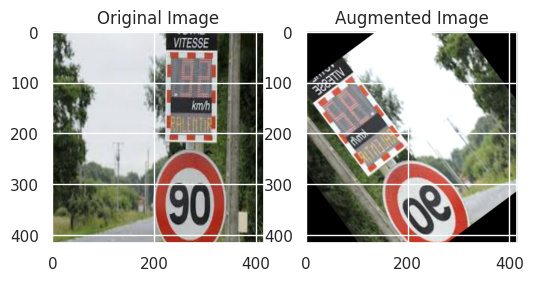

In [ ]:
# Step 9: Visualization of Augmented Images
def visualize_augmentation(image_path):
    # Read the image
    image = cv2.imread(image_path)

    # Apply the augmentation
    augmented_image = augment_image(image)

    plt.figure(figsize=(6, 6))

    # Display the original image
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")

    # Display the augmented image
    plt.subplot(1, 2, 2)

    # Convert tensor to numpy and reorder dimensions for OpenCV
    augmented_image_np = augmented_image.permute(1, 2, 0).cpu().numpy()  # Reorder channels to (H, W, C)

    # Rescale the pixel values to 0-255 (scaled by 255)
    augmented_image_np = np.clip(augmented_image_np * 255, 0, 255).astype(np.uint8)

    plt.imshow(cv2.cvtColor(augmented_image_np, cv2.COLOR_BGR2RGB))  # Convert to RGB for display
    plt.title("Augmented Image")
    plt.show()

# Visualize a few augmentations
image_sample = train_images[4]  # Use any image path for testing
visualize_augmentation(image_sample)

In [ ]:
#Train the Model with the Augmentation Pipeline
train_data = '/content/car/data.yaml'

# Modify hyperparameters if needed
model.train(data=train_data, epochs=30, batch=-1, imgsz=640, nbs=64)

Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: task=detect, mode=train, model=yolov8m.pt, data=/content/car/data.yaml, epochs=30, time=None, patience=100, batch=-1, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, show_boxes=True, li

100%|██████████| 755k/755k [00:00<00:00, 14.2MB/s]


Overriding model.yaml nc=80 with nc=15

                   from  n    params  module                                       arguments                     
  0                  -1  1      1392  ultralytics.nn.modules.conv.Conv             [3, 48, 3, 2]                 
  1                  -1  1     41664  ultralytics.nn.modules.conv.Conv             [48, 96, 3, 2]                
  2                  -1  2    111360  ultralytics.nn.modules.block.C2f             [96, 96, 2, True]             
  3                  -1  1    166272  ultralytics.nn.modules.conv.Conv             [96, 192, 3, 2]               
  4                  -1  4    813312  ultralytics.nn.modules.block.C2f             [192, 192, 4, True]           
  5                  -1  1    664320  ultralytics.nn.modules.conv.Conv             [192, 384, 3, 2]              
  6                  -1  4   3248640  ultralytics.nn.modules.block.C2f             [384, 384, 4, True]           
  7                  -1  1   1991808  ultralytic

100%|██████████| 5.35M/5.35M [00:00<00:00, 43.3MB/s]


AMP: checks passed ✅
train: Fast image access ✅ (ping: 0.0±0.0 ms, read: 927.3±363.5 MB/s, size: 24.1 KB)


...

                   all        801        944       0.96       0.92      0.965      0.844



30 epochs completed in 0.233 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 52.0MB
Optimizer stripped from runs/detect/train/weights/best.pt, 52.0MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Model summary (fused): 92 layers, 25,848,445 parameters, 0 gradients, 78.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 9/9 [00:04<00:00,  1.90it/s]


                   all        801        944      0.945      0.928      0.969      0.846
           Green Light         87        122      0.879      0.774       0.89       0.54
             Red Light         74        108       0.83      0.787      0.837      0.551
       Speed Limit 100         52         52      0.894      0.973      0.984      0.895
       Speed Limit 110         17         17      0.939      0.882      0.968      0.891
       Speed Limit 120         60         60      0.978      0.983      0.993      0.916
        Speed Limit 20         56         56      0.984      0.982      0.986       0.88
        Speed Limit 30         71         74      0.942      0.959      0.991      0.928
        Speed Limit 40         53         55      0.943      0.982      0.992       0.89
        Speed Limit 50         68         71      0.944      0.944      0.987      0.887
        Speed Limit 60         76         76      0.939      0.947      0.978      0.886
        Speed Limit 7

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a6f6d17a4d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.0

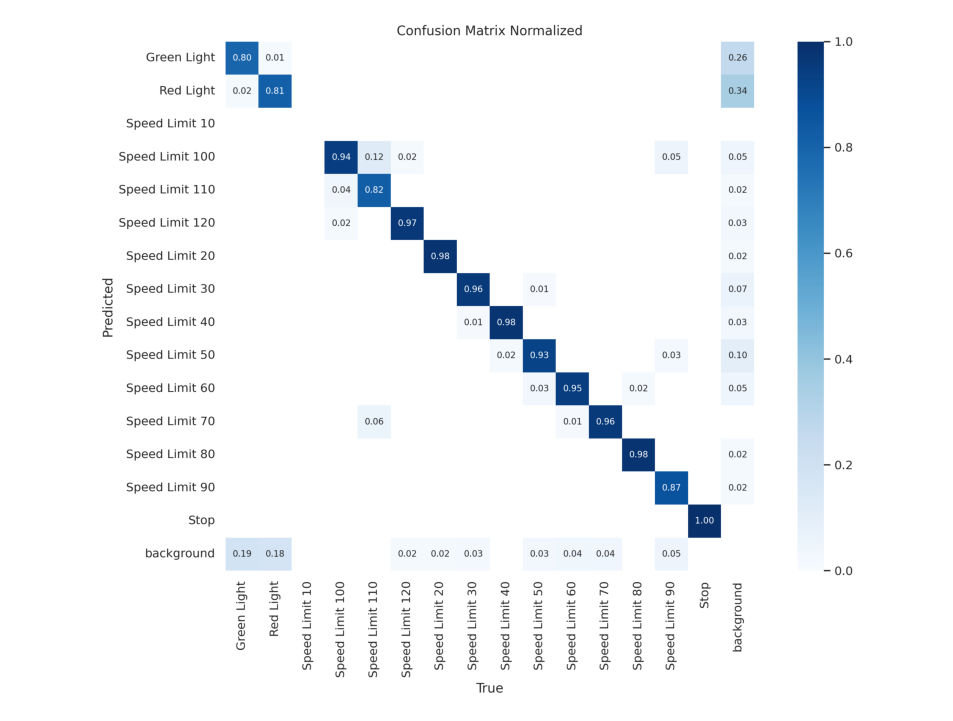

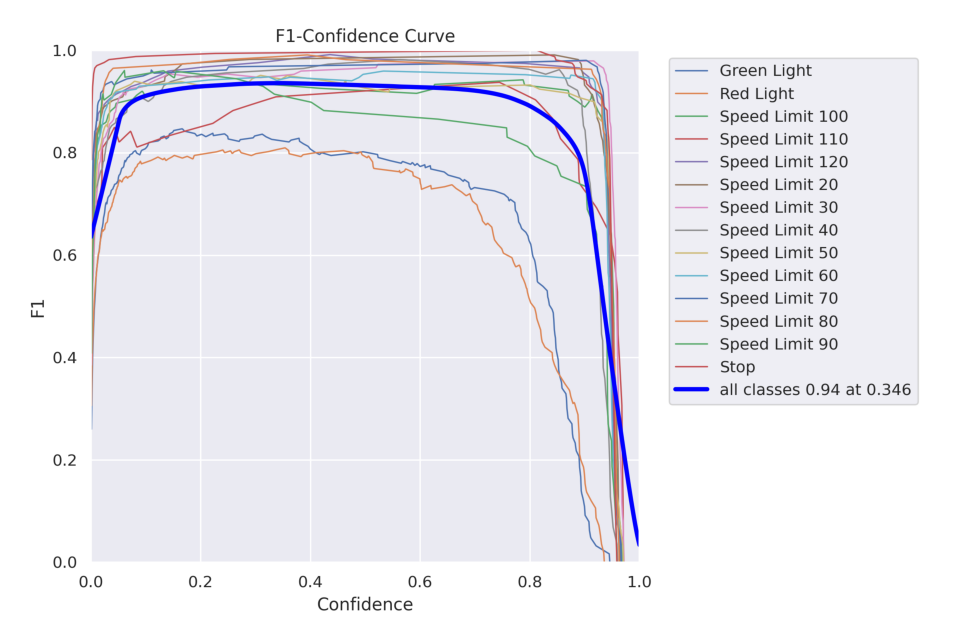

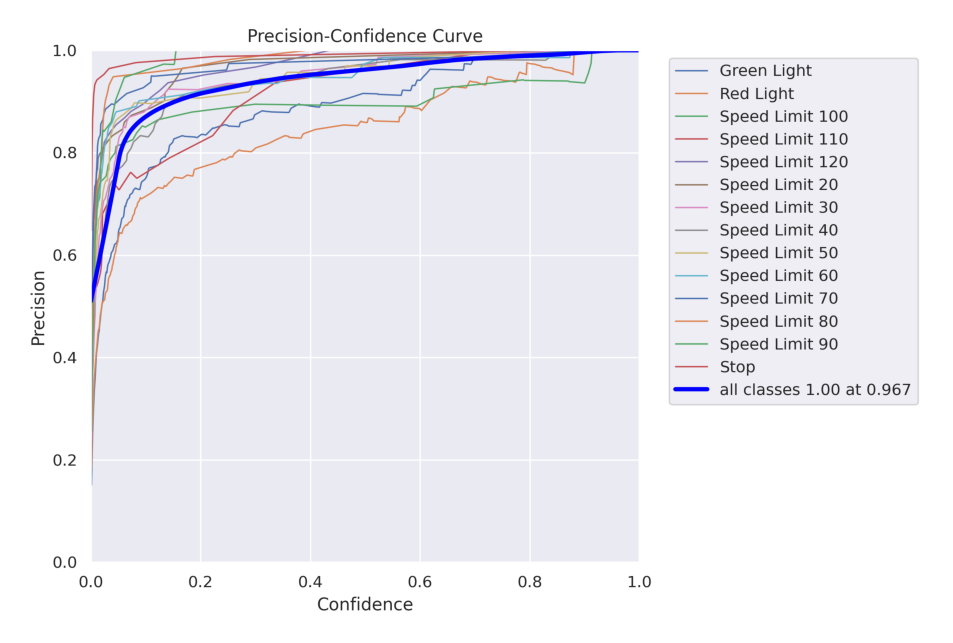

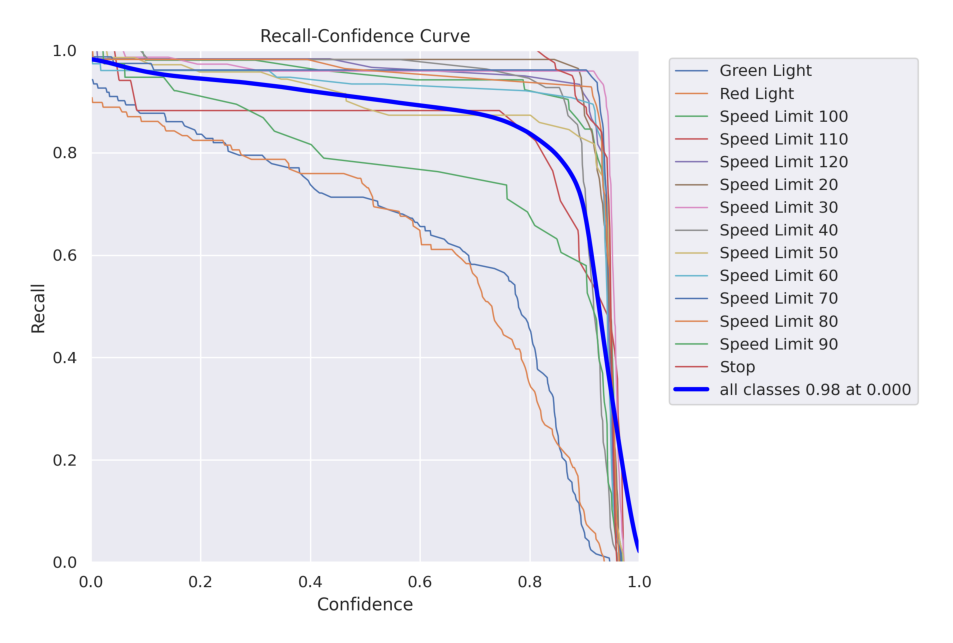

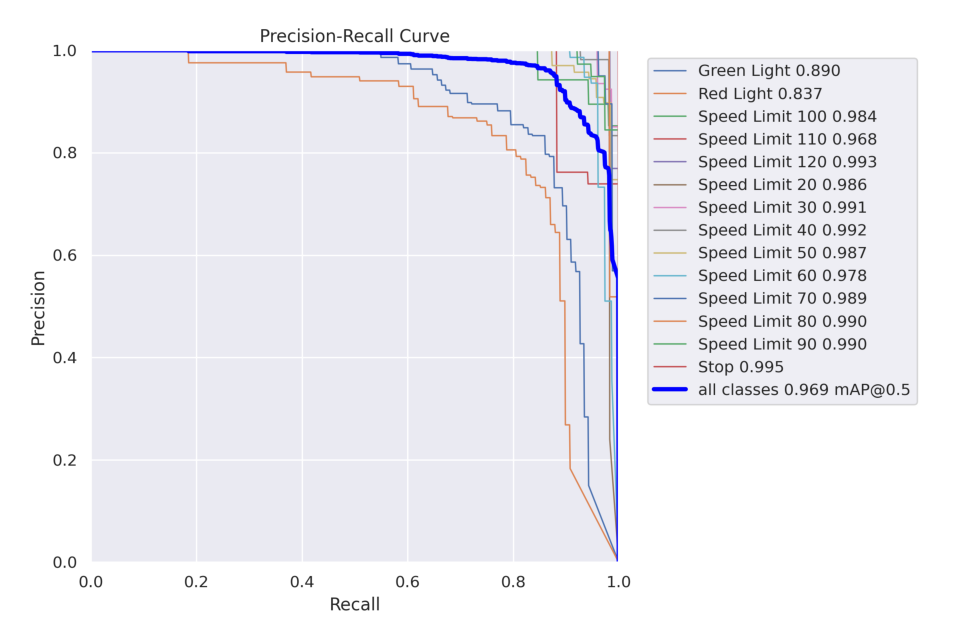

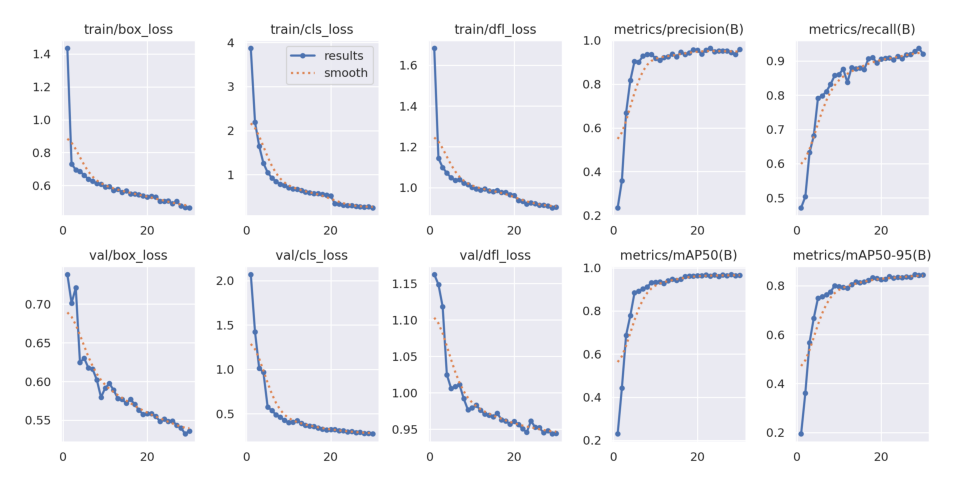

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

def display_images(post_training_files_path, image_files):

    for image_file in image_files:
        image_path = os.path.join(post_training_files_path, image_file)
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(10, 10), dpi=120)
        plt.imshow(img)
        plt.axis('off')
        plt.show()

# List of image files to display
image_files = [
    'confusion_matrix_normalized.png',
    'F1_curve.png',
    'P_curve.png',
    'R_curve.png',
    'PR_curve.png',
    'results.png'
]

# Path to the directory containing the images
post_training_files_path = '/content/runs/detect/train'

# Display the images
display_images(post_training_files_path, image_files)

In [ ]:
Result_Final_model = pd.read_csv('/content/runs/detect/train/results.csv')
Result_Final_model.tail(10)

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
20,21,588.362,0.53383,0.34264,0.93766,0.93758,0.90817,0.96281,0.82697,0.55858,0.32199,0.95637,0.000179,0.000179,0.000179
21,22,616.117,0.52906,0.33776,0.93286,0.95615,0.90900,0.96627,0.83837,0.55514,0.30790,0.95073,0.000161,0.000161,0.000161
22,23,643.931,0.50486,0.30781,0.91969,0.96375,0.90368,0.96202,0.83056,0.54859,0.30919,0.94579,0.000144,0.000144,0.000144
23,24,671.617,0.50283,0.29889,0.92625,0.94860,0.91386,0.96780,0.83485,0.55150,0.29831,0.96161,0.000127,0.000127,0.000127
24,25,699.289,0.50493,0.29620,0.92111,0.95135,0.90615,0.95917,0.83295,0.54853,0.29974,0.95263,0.000109,0.000109,0.000109
25,26,726.885,0.48850,0.27827,0.91372,0.95170,0.91828,0.96647,0.83550,0.54920,0.28955,0.95219,0.000092,0.000092,0.000092
26,27,754.526,0.50298,0.27399,0.91475,0.95113,0.91875,0.96378,0.83472,0.54361,0.29258,0.94526,0.000075,0.000075,0.000075
27,28,782.062,0.47524,0.26323,0.91063,0.94522,0.92818,0.96938,0.84597,0.54010,0.27976,0.94787,0.000057,0.000057,0.000057
28,29,809.889,0.46518,0.27245,0.90156,0.93648,0.93691,0.96389,0.84249,0.53244,0.27861,0.94382,0.000040,0.000040,0.000040
29,30,837.481,0.46473,0.25123,0.90465,0.95953,0.92024,0.96536,0.84352,0.53614,0.27437,0.94446,0.000023,0.000023,0.000023


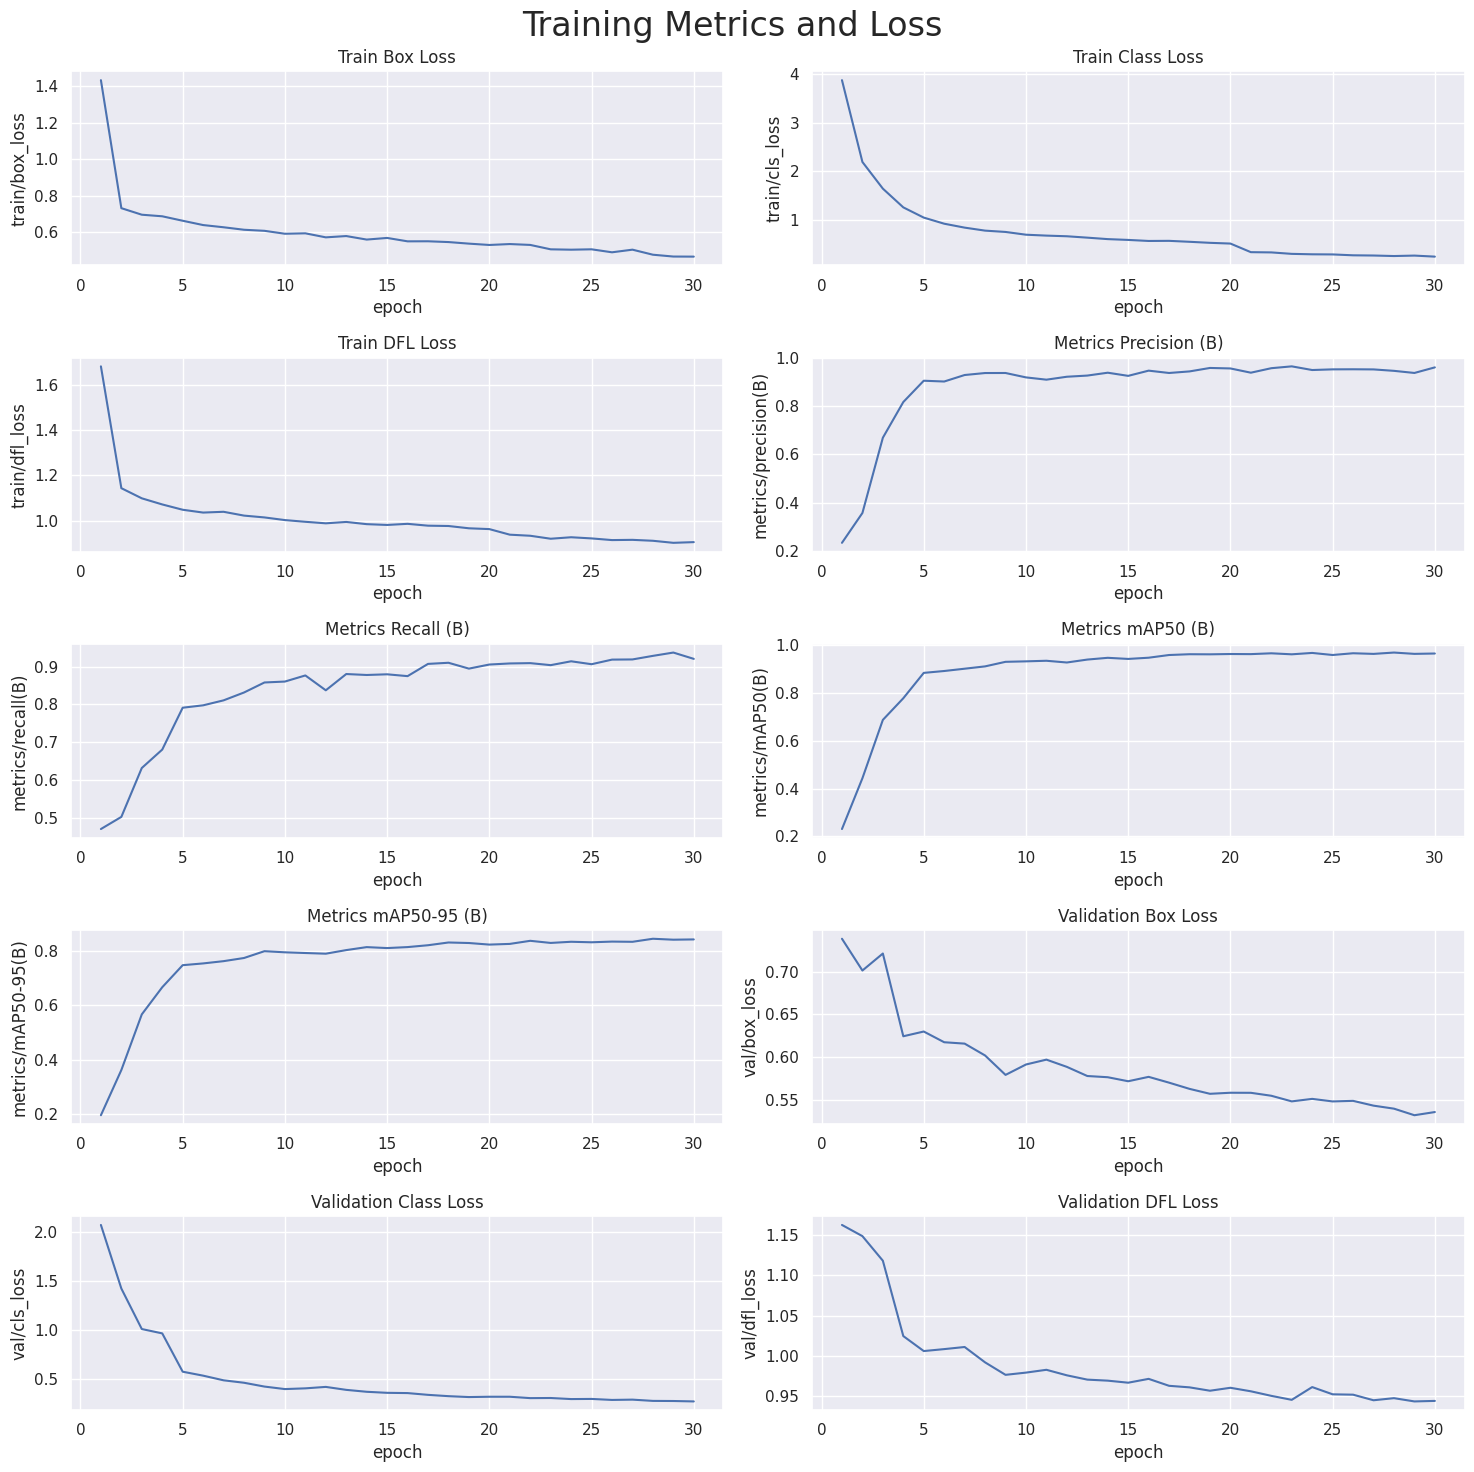

In [ ]:
# Read the results.csv file as a pandas dataframe
Result_Final_model.columns = Result_Final_model.columns.str.strip()

# Create subplots
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(15, 15))

# Plot the columns using seaborn
sns.lineplot(x='epoch', y='train/box_loss', data=Result_Final_model, ax=axs[0,0])
sns.lineplot(x='epoch', y='train/cls_loss', data=Result_Final_model, ax=axs[0,1])
sns.lineplot(x='epoch', y='train/dfl_loss', data=Result_Final_model, ax=axs[1,0])
sns.lineplot(x='epoch', y='metrics/precision(B)', data=Result_Final_model, ax=axs[1,1])
sns.lineplot(x='epoch', y='metrics/recall(B)', data=Result_Final_model, ax=axs[2,0])
sns.lineplot(x='epoch', y='metrics/mAP50(B)', data=Result_Final_model, ax=axs[2,1])
sns.lineplot(x='epoch', y='metrics/mAP50-95(B)', data=Result_Final_model, ax=axs[3,0])
sns.lineplot(x='epoch', y='val/box_loss', data=Result_Final_model, ax=axs[3,1])
sns.lineplot(x='epoch', y='val/cls_loss', data=Result_Final_model, ax=axs[4,0])
sns.lineplot(x='epoch', y='val/dfl_loss', data=Result_Final_model, ax=axs[4,1])

# Set titles and axis labels for each subplot
axs[0,0].set(title='Train Box Loss')
axs[0,1].set(title='Train Class Loss')
axs[1,0].set(title='Train DFL Loss')
axs[1,1].set(title='Metrics Precision (B)')
axs[2,0].set(title='Metrics Recall (B)')
axs[2,1].set(title='Metrics mAP50 (B)')
axs[3,0].set(title='Metrics mAP50-95 (B)')
axs[3,1].set(title='Validation Box Loss')
axs[4,0].set(title='Validation Class Loss')
axs[4,1].set(title='Validation DFL Loss')


plt.suptitle('Training Metrics and Loss', fontsize=24)
plt.subplots_adjust(top=0.8)
plt.tight_layout()
plt.show()

In [ ]:
# Loading the best performing model
Valid_model = YOLO('/content/runs/detect/train/weights/best.pt')

# Evaluating the model on the validset
metrics = Valid_model.val(split = 'val')

# final results
print("precision(B): ", metrics.results_dict["metrics/precision(B)"])
print("metrics/recall(B): ", metrics.results_dict["metrics/recall(B)"])
print("metrics/mAP50(B): ", metrics.results_dict["metrics/mAP50(B)"])
print("metrics/mAP50-95(B): ", metrics.results_dict["metrics/mAP50-95(B)"])

Ultralytics 8.3.115 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
Model summary (fused): 92 layers, 25,848,445 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 540.5±296.9 MB/s, size: 11.2 KB)


val: Scanning /content/car/valid/labels.cache... 801 images, 0 backgrounds, 0 corrupt: 100%|██████████| 801/801 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 51/51 [00:06<00:00,  8.31it/s]


                   all        801        944      0.945      0.928      0.969      0.846
           Green Light         87        122      0.879      0.774      0.892      0.539
             Red Light         74        108      0.828      0.787      0.835      0.547
       Speed Limit 100         52         52      0.894      0.972      0.984      0.896
       Speed Limit 110         17         17      0.938      0.882      0.968        0.9
       Speed Limit 120         60         60      0.979      0.983      0.993      0.917
        Speed Limit 20         56         56      0.984      0.982      0.986      0.881
        Speed Limit 30         71         74      0.942      0.959      0.991      0.929
        Speed Limit 40         53         55      0.943      0.982      0.992      0.889
        Speed Limit 50         68         71      0.948      0.944      0.987      0.888
        Speed Limit 60         76         76      0.939      0.947      0.978      0.888
        Speed Limit 7

In [ ]:
# Normalization function
def normalize_image(image):
    return image / 255.0

# Image resizing function
def resize_image(image, size=(640, 640)):
    return cv2.resize(image, size)

# Path to validation images
dataset_path = '/content/car'
valid_images_path = os.path.join(dataset_path, 'test', 'images')

# List of all jpg images in the directory
image_files = [file for file in os.listdir(valid_images_path) if file.endswith('.jpg')]

# Check if there are images in the directory
if len(image_files) > 0:
    # Select 9 images at equal intervals
    num_images = len(image_files)
    step_size = max(1, num_images // 9)  # Ensure the interval is at least 1
    selected_images = [image_files[i] for i in range(0, num_images, step_size)]

    # Prepare subplots
    fig, axes = plt.subplots(3, 3, figsize=(20, 21))
    fig.suptitle('Validation Set Inferences', fontsize=24)

    for i, ax in enumerate(axes.flatten()):
        if i < len(selected_images):
            image_path = os.path.join(valid_images_path, selected_images[i])

            # Load image
            image = cv2.imread(image_path)

            # Check if the image is loaded correctly
            if image is not None:
                # Resize image
                resized_image = resize_image(image, size=(640, 640))
                # Normalize image
                normalized_image = normalize_image(resized_image)

                # Convert the normalized image to uint8 data type
                normalized_image_uint8 = (normalized_image * 255).astype(np.uint8)

                # Predict with the model
                results = Valid_model.predict(source=normalized_image_uint8, imgsz=640, conf=0.5)

                # Plot image with labels
                annotated_image = results[0].plot(line_width=1)
                annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
                ax.imshow(annotated_image_rgb)
            else:
                print(f"Failed to load image {image_path}")
        ax.axis('off')

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

Evaluating brightness:   0%|          | 0/20 [00:00<?, ?it/s]


0: 640x640 2 Green Lights, 11.2ms
Speed: 2.8ms preprocess, 11.2ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Green Light, 9.5ms
Speed: 2.7ms preprocess, 9.5ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 80, 9.3ms
Speed: 2.5ms preprocess, 9.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 80, 9.6ms
Speed: 2.6ms preprocess, 9.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 30, 10.0ms
Speed: 2.6ms preprocess, 10.0ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Red Light, 9.4ms
Speed: 3.0ms preprocess, 9.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 60, 9.3ms
Speed: 2.5ms preprocess, 9.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 80, 9.2ms
Speed: 2.6ms preprocess, 9.2ms inference, 1.4m

Evaluating contrast:   0%|          | 0/20 [00:00<?, ?it/s]


0: 640x640 2 Green Lights, 9.4ms
Speed: 2.7ms preprocess, 9.4ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Green Light, 9.4ms
Speed: 2.5ms preprocess, 9.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 80, 9.3ms
Speed: 2.6ms preprocess, 9.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 80, 9.6ms
Speed: 2.5ms preprocess, 9.6ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 30, 9.9ms
Speed: 2.6ms preprocess, 9.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Red Light, 9.5ms
Speed: 2.6ms preprocess, 9.5ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 60, 9.7ms
Speed: 2.6ms preprocess, 9.7ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 80, 9.6ms
Speed: 2.5ms preprocess, 9.6ms inference, 1.5ms po

Evaluating rotate:   0%|          | 0/20 [00:00<?, ?it/s]


0: 640x640 2 Green Lights, 10.5ms
Speed: 3.4ms preprocess, 10.5ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Green Light, 9.3ms
Speed: 2.5ms preprocess, 9.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 60, 9.4ms
Speed: 2.6ms preprocess, 9.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 80, 9.3ms
Speed: 2.6ms preprocess, 9.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 30, 1 Speed Limit 80, 9.4ms
Speed: 2.5ms preprocess, 9.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Red Light, 10.4ms
Speed: 2.7ms preprocess, 10.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 60, 9.8ms
Speed: 2.9ms preprocess, 9.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 80, 9.7ms
Speed: 2.6ms preprocess, 9.7

Evaluating flip:   0%|          | 0/20 [00:00<?, ?it/s]


0: 640x640 2 Green Lights, 9.9ms
Speed: 3.0ms preprocess, 9.9ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Green Light, 9.8ms
Speed: 2.5ms preprocess, 9.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 80, 11.2ms
Speed: 2.9ms preprocess, 11.2ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 80, 10.0ms
Speed: 2.6ms preprocess, 10.0ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 30, 10.0ms
Speed: 2.5ms preprocess, 10.0ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Red Light, 10.5ms
Speed: 2.5ms preprocess, 10.5ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 60, 9.8ms
Speed: 2.6ms preprocess, 9.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 80, 9.7ms
Speed: 2.6ms preprocess, 9.7ms inference, 

Evaluating blur:   0%|          | 0/20 [00:00<?, ?it/s]


0: 640x640 2 Green Lights, 12.1ms
Speed: 3.1ms preprocess, 12.1ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Green Light, 9.5ms
Speed: 2.6ms preprocess, 9.5ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 80, 9.4ms
Speed: 2.6ms preprocess, 9.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 80, 9.5ms
Speed: 2.8ms preprocess, 9.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 30, 9.5ms
Speed: 2.6ms preprocess, 9.5ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Red Light, 9.5ms
Speed: 2.7ms preprocess, 9.5ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 60, 9.6ms
Speed: 2.7ms preprocess, 9.6ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 80, 10.6ms
Speed: 2.7ms preprocess, 10.6ms inference, 1.5m

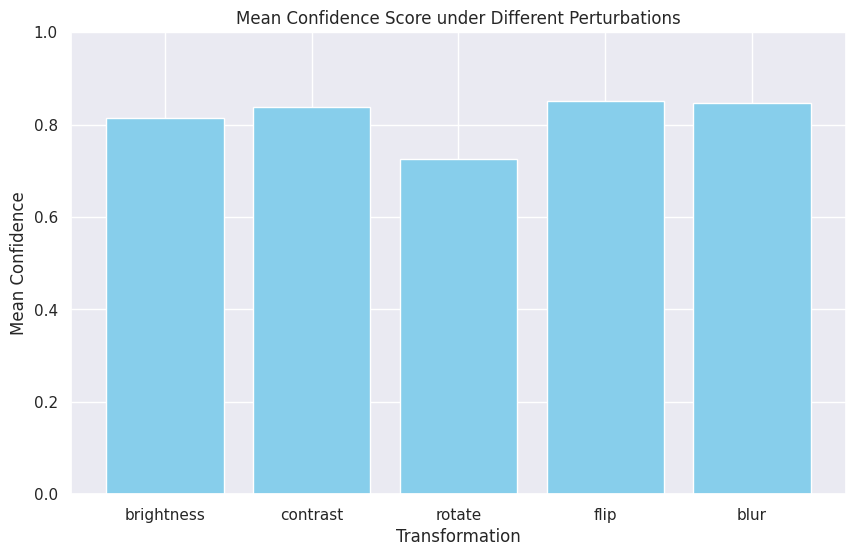

In [ ]:
# Required Libraries
import os
import cv2
import numpy as np
import pandas as pd
import albumentations as A
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from ultralytics import YOLO

# Load your trained model
model = YOLO('/content/runs/detect/train/weights/best.pt')

# Define robustness transformations
transformations = {
    "brightness": A.RandomBrightnessContrast(brightness_limit=0.3, p=1),
    "contrast": A.RandomBrightnessContrast(contrast_limit=0.3, p=1),
    "rotate": A.Rotate(limit=40, p=0.5),
    "flip": A.HorizontalFlip(p=0.5),
    "blur": A.MotionBlur(blur_limit=7, p=0.1)
}

# Path to test images
valid_images_path = "/content/car/test/images"
image_files = [f for f in os.listdir(valid_images_path) if f.endswith('.jpg')]

# Evaluation function
def evaluate_robustness(image_path, transform_name, transform):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    augmented = transform(image=image)['image']
    augmented_bgr = cv2.cvtColor(augmented, cv2.COLOR_RGB2BGR)

    results = model.predict(source=augmented_bgr, imgsz=640, conf=0.25)
    conf_scores = [float(bbox.conf[0]) for bbox in results[0].boxes]

    return np.mean(conf_scores) if conf_scores else 0.0

# Main robustness loop
robust_results = []

for transform_name, transform in transformations.items():
    scores = []
    for image_file in tqdm(image_files[:20], desc=f"Evaluating {transform_name}"):
        image_path = os.path.join(valid_images_path, image_file)
        score = evaluate_robustness(image_path, transform_name, transform)
        scores.append(score)

    robust_results.append({
        "Transformation": transform_name,
        "Mean Confidence": np.mean(scores),
        "Min Confidence": np.min(scores),
        "Max Confidence": np.max(scores)
    })

# Create DataFrame from results
robust_df = pd.DataFrame(robust_results)

# Print Results Table
print("=== YOLOv8 Robustness Evaluation Results ===\n")
print(robust_df.to_string(index=False))

# Bar Chart of Mean Confidence
plt.figure(figsize=(10, 6))
plt.bar(robust_df['Transformation'], robust_df['Mean Confidence'], color='skyblue')
plt.title('Mean Confidence Score under Different Perturbations')
plt.ylabel('Mean Confidence')
plt.xlabel('Transformation')
plt.ylim(0, 1)
plt.grid(True)
plt.show()


0: 640x640 1 Speed Limit 20, 9.5ms
Speed: 2.8ms preprocess, 9.5ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)


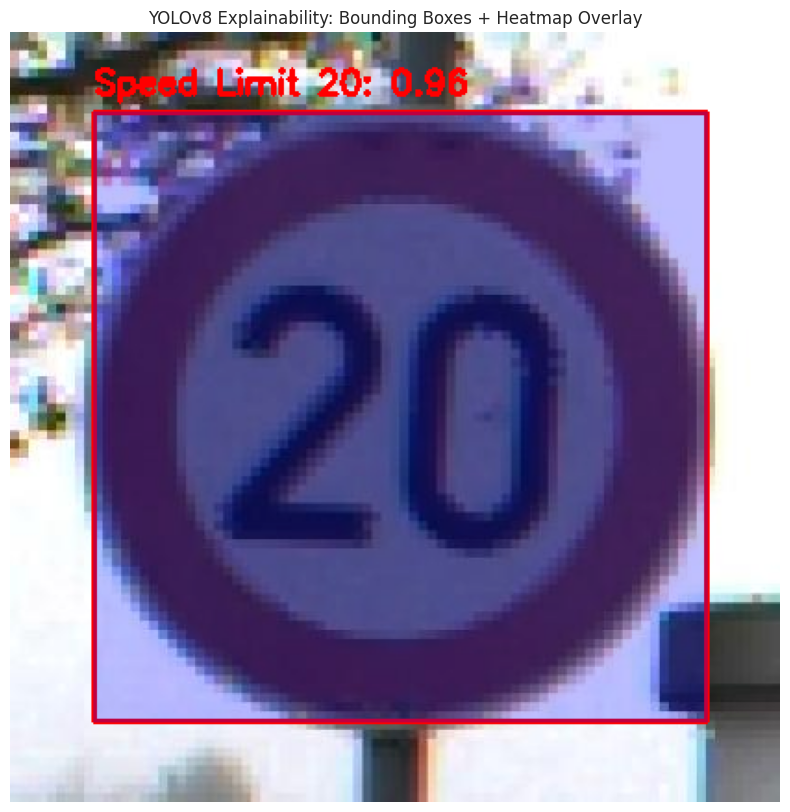

In [ ]:
# ✅ Load your trained YOLOv8 model
model = YOLO('/content/runs/detect/train/weights/best.pt')  # Adjust path if needed

# ✅ Pick an image for explanation (replace with your own image path)
image_path = '/content/car/test/images/00000_00002_00026_png.rf.092c69361ef48fd43b479aa48fc829d9.jpg'  # ← Replace with a real test image
image_bgr = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# 🧠 Run inference
results = model.predict(image_rgb, conf=0.25, imgsz=640)

# 🎯 Extract predictions
boxes = results[0].boxes
annotated_image = image_rgb.copy()

# 🖍️ Loop through predictions and draw explainability overlays
for i in range(len(boxes)):
    box = boxes[i]
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    conf = float(box.conf[0])
    cls_id = int(box.cls[0])
    label = f'{model.names[cls_id]}: {conf:.2f}'

    # Draw bounding box
    cv2.rectangle(annotated_image, (x1, y1), (x2, y2), (255, 0, 0), 2)
    # Add label
    cv2.putText(annotated_image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    # 🔥 Simulate heatmap-style transparency overlay
    overlay = annotated_image.copy()
    alpha = 0.25  # Transparency factor
    cv2.rectangle(overlay, (x1, y1), (x2, y2), (0, 0, 255), -1)  # Red transparent box
    annotated_image = cv2.addWeighted(overlay, alpha, annotated_image, 1 - alpha, 0)

# 📸 Show the final image with explanations
plt.figure(figsize=(10, 10))
plt.imshow(annotated_image)
plt.axis('off')
plt.title('YOLOv8 Explainability: Bounding Boxes + Heatmap Overlay')
plt.show()


0: 640x640 1 Speed Limit 20, 10.2ms
Speed: 2.9ms preprocess, 10.2ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Speed Limit 30, 10.2ms
Speed: 3.1ms preprocess, 10.2ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Red Light, 1 Stop, 9.9ms
Speed: 2.7ms preprocess, 9.9ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Green Light, 1 Red Light, 1 Stop, 9.8ms
Speed: 2.7ms preprocess, 9.8ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Green Light, 9.8ms
Speed: 2.7ms preprocess, 9.8ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Green Light, 1 Red Light, 9.8ms
Speed: 2.7ms preprocess, 9.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Stop, 9.7ms
Speed: 2.6ms preprocess, 9.7ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 Red Light, 1 Speed Limit 20, 9.7ms
Speed

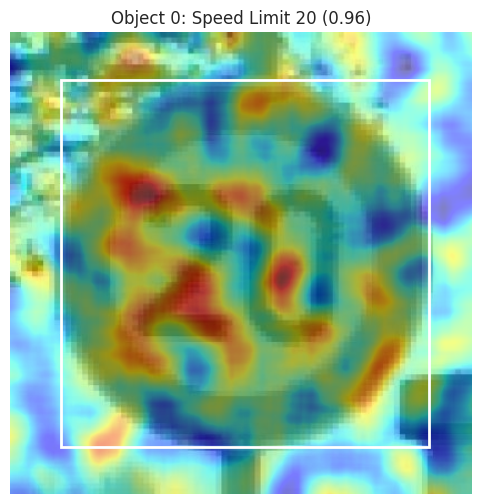

In [ ]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO
from typing import List, Tuple

# ─── 1) Mask Generator ───────────────────────────────────────────────────────────
class MaskGenerator:
    """
    Generates N randomized RISE masks of size H×W, following D-RISE:
      1. Sample h×w binary masks with p(1)=p
      2. Upsample to (h+1)*CH × (w+1)*CW via bilinear interp
      3. Randomly crop H×W from them
    """
    def __init__(self, H:int, W:int, h:int, w:int, p:float, N:int):
        self.H, self.W = H, W
        self.h, self.w = h, w
        self.p, self.N = p, N
        # cell size
        self.CH = H // h
        self.CW = W // w

    def generate(self) -> np.ndarray:
        """
        Returns:
          masks: np.ndarray of shape (N, H, W), float32 in {0,1}
        """
        # 1) sample small binary masks
        small = np.random.binomial(1, self.p,
                                   size=(self.N, self.h, self.w)).astype(np.float32)
        # 2) upsample via OpenCV
        up_h = (self.h + 1) * self.CH
        up_w = (self.w + 1) * self.CW
        masks = np.zeros((self.N, up_h, up_w), dtype=np.float32)
        for i in range(self.N):
            masks[i] = cv2.resize(small[i], dsize=(up_w, up_h),
                                  interpolation=cv2.INTER_LINEAR)
        # 3) random crop H×W
        out = np.zeros((self.N, self.H, self.W), dtype=np.float32)
        for i in range(self.N):
            y = np.random.randint(0, up_h - self.H + 1)
            x = np.random.randint(0, up_w - self.W + 1)
            out[i] = masks[i, y:y+self.H, x:x+self.W]
        return out

# ─── 2) Utility: IoU and Cosine Similarity ───────────────────────────────────────
def iou(boxA: np.ndarray, boxB: np.ndarray) -> float:
    # box = [x1,y1,x2,y2]
    xA = max(boxA[0], boxB[0]); yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2]); yB = min(boxA[3], boxB[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    areaA = (boxA[2]-boxA[0])*(boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0])*(boxB[3]-boxB[1])
    union = areaA + areaB - inter
    return inter/union if union>0 else 0.0

def cosine_sim(p: np.ndarray, q: np.ndarray) -> float:
    # assume p,q ≥0
    num = p.dot(q)
    den = np.linalg.norm(p)*np.linalg.norm(q)
    return float(num/den) if den>0 else 0.0

# ─── 3) D-RISE Explainer ──────────────────────────────────────────────────────────
class DRISEExplainer:
    def __init__(self, model: YOLO, mask_gen: MaskGenerator, device:str='cuda'):
        self.model = model
        self.mask_gen = mask_gen
        self.device = device
        model.model.to(device)

    def _run_detector(self, img: np.ndarray) -> List[Tuple[np.ndarray, float, np.ndarray]]:
        """
        Run YOLO and return list of detections:
          [(box, object_conf, class_probs), ...]
        box = [x1,y1,x2,y2], class_probs is one-hot vector length=C
        """
        results = self.model.predict(img, device=self.device, conf=0.01)[0]
        dets = []
        C = len(self.model.names)
        for box in results.boxes:
            x1,y1,x2,y2 = box.xyxy[0].cpu().numpy()
            conf = float(box.conf[0].cpu().numpy())  # combined score
            cls = int(box.cls[0].cpu().numpy())
            # build one-hot prob vector
            P = np.zeros(C, dtype=np.float32)
            P[cls] = conf
            dets.append((np.array([x1,y1,x2,y2]), conf, P))
        return dets

    def explain(self, image: np.ndarray) -> np.ndarray:
        """
        image: H×W×3 uint8 RGB
        returns: S of shape (T, H, W) saliency maps, one per original detection
        """
        H, W, _ = image.shape
        # 1) original detections
        Dt = self._run_detector(image)
        T = len(Dt)
        if T == 0:
            raise ValueError("No objects detected in original image.")

        # 2) generate masks
        masks = self.mask_gen.generate()  # (N,H,W)
        N = masks.shape[0]

        # 3) run detector on masked images
        Wit = np.zeros((N, T), dtype=np.float32)
        for i in range(N):
            # apply mask
            masked = (image.astype(np.float32)/255.0) * masks[i][...,None]
            masked = (masked*255).astype(np.uint8)
            Dp = self._run_detector(masked)

            # 4) compute weights per detection t
            for t in range(T):
                Lt, Ot, Pt = Dt[t]
                best = 0.0
                for Lp, Op, Pp in Dp:
                    # only consider same-class proposals (cosine will be 0 else)
                    sim = iou(Lt, Lp) * cosine_sim(Pt, Pp)
                    if sim > best:
                        best = sim
                Wit[i, t] = best

        # 5) aggregate saliency maps
        S = np.zeros((T, H, W), dtype=np.float32)
        for t in range(T):
            # weighted sum over masks
            S[t] = (Wit[:, t][:,None,None] * masks).sum(axis=0) / N

        return S, Dt

# ─── 4) Usage Example ─────────────────────────────────────────────────────────────

if __name__ == "__main__":
    # 4.1 Load your trained YOLOv8
    model = YOLO('/content/runs/detect/train/weights/best.pt')

    # 4.2 Read and prepare the image
    img_path = '/content/car/test/images/00000_00002_00026_png.rf.092c69361ef48fd43b479aa48fc829d9.jpg'
    bgr = cv2.imread(img_path)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    H, W, _ = rgb.shape
    # 4.3 Create MaskGenerator (e.g. N=500, grid 16×16, p=0.5)
    mask_gen = MaskGenerator(H, W, h=16, w=16, p=0.5, N=500)

    # 4.4 Instantiate DRISE and explain
    explainer = DRISEExplainer(model, mask_gen, device='cuda')
    saliency_maps, detections = explainer.explain(rgb)

    # 4.5 Overlay and plot each saliency map
    for idx, ((box, conf, P), S) in enumerate(zip(detections, saliency_maps)):
        plt.figure(figsize=(6,6))
        plt.imshow(rgb)
        # overlay heatmap
        plt.imshow(S, cmap='jet', alpha=0.5)
        x1,y1,x2,y2 = box
        plt.gca().add_patch(plt.Rectangle((x1,y1), x2-x1, y2-y1,
                                          fill=False, edgecolor='white', linewidth=2))
        plt.title(f"Object {idx}: {model.names[P.argmax()]} ({conf:.2f})")
        plt.axis('off')
    plt.show()
